In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from PIL import Image
import os

# Define the directory where your images are stored
input_directory = 'path_to_your_images'
output_directory = 'path_to_save_resized_images'

# Ensure the output directory exists
os.makedirs(output_directory, exist_ok=True)

# Function to resize image to 530x530
def resize_image(image_path, output_path):
    with Image.open(image_path) as img:
        # Resize the image to 530x530
        resized_img = img.resize((530, 530))
        # Save the resized image
        resized_img.save(output_path)

# Loop over all images in the input directory
for filename in os.listdir(input_directory):
    if filename.endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):  # Add other image formats if needed
        input_path = os.path.join(input_directory, filename)
        output_path = os.path.join(output_directory, filename)
        resize_image(input_path, output_path)

print("All images have been resized to 530x530.")


(530, 530, 3)


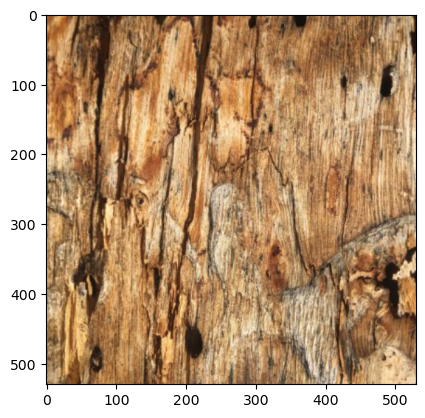

In [6]:
image = Image.open('Assignment2/1.png')
image_array = np.array(image)
image_array = image_array[:,:,:3]
sample_size = image_array.shape

# rand_number_h = np.random.choice(np.arange(image_array.shape[0] - sample_size), size=1,
#                                  p=np.ones(image_array.shape[0] - sample_size) / float(image_array.shape[0] - sample_size))
# rand_number_w = np.random.choice(np.arange(image_array.shape[1] - sample_size), size=1,
#                                  p=np.ones(image_array.shape[1] - sample_size) / float(image_array.shape[1] - sample_size))
# image_array = image_array[rand_number_h[0]:rand_number_h[0] + sample_size, rand_number_w[0]:rand_number_w[0] + sample_size]

print(sample_size)
#fig, axes = plt.subplots(1,2, figsize=(10,10))
plt.imshow(image_array)
#plt.set_title('full image')

In [7]:
def init_gpu(original_sample, kernel_size, gen_size):
    sh, sw, _ = original_sample.shape
    # Convert original to sample representation.
    sample = cv2.cvtColor(original_sample, cv2.COLOR_BGR2GRAY)
    
    # Convert sample to floating point and normalize to the range [0., 1.]
    sample = sample.astype(np.float64)
    sample = sample / 255.
    sample_tensor = torch.tensor(sample, dtype=torch.float32, device=device).reshape(1, sh, sw)
    print(sample_tensor.shape)
    patches = torch.nn.functional.unfold(sample_tensor, kernel_size=kernel_size, stride=1)
    print(patches.shape)
    permute_patches = patches.permute(1,0)
    print(permute_patches.shape)
    patches = permute_patches.reshape(-1, kernel_size, kernel_size)
    print(patches.shape)

    # Generate window
    window = np.zeros(gen_size, dtype=np.float64)

    # Generate output window
    if original_sample.ndim == 2:
        result_window = np.zeros_like(window, dtype=np.uint8)
    else:
        result_window = np.zeros(gen_size + (3,), dtype=np.uint8)

    # Generate window mask
    h, w = window.shape
    mask = np.zeros((h, w), dtype=np.float64)

    # Initialize window with random seed from sample
    sh, sw = original_sample.shape[:2]
    ih = 20#np.random.randint(sh-3+1)
    iw = 20#np.random.randint(sw-3+1)
    seed = sample[ih:ih+3, iw:iw+3]
    noise = np.random.uniform(-0.1, 0.1, (3, 3))
    noisy = seed + noise
    seed = np.clip(noisy, 0, 1)



    # Place seed in center of window
    ph, pw = (h//2)-1, (w//2)-1
    window[ph:ph+3, pw:pw+3] = seed
    mask[ph:ph+3, pw:pw+3] = 1
    result_window[ph:ph+3, pw:pw+3] = original_sample[ih:ih+3, iw:iw+3]

    # Obtain padded versions of window and mask
    win = kernel_size//2
    padded_window = cv2.copyMakeBorder(window, 
                                       top=win, bottom=win, left=win, right=win, borderType=cv2.BORDER_CONSTANT, value=0.)
    padded_mask = cv2.copyMakeBorder(mask,
                                     top=win, bottom=win, left=win, right=win, borderType=cv2.BORDER_CONSTANT, value=0.)
    
    # Obtain views of the padded window and mask
    window = padded_window[win:-win, win:-win]
    mask = padded_mask[win:-win, win:-win]

    return patches, window, mask, padded_window, padded_mask, result_window

def init_cpu(original_sample, kernel_size, window_size):
    # Convert original to sample representation.
    sample = cv2.cvtColor(original_sample, cv2.COLOR_BGR2GRAY)
    
    # Convert sample to floating point and normalize to the range [0., 1.]
    sample = sample.astype(np.float64)
    sample = sample / 255.

    # Generate window
    window = np.zeros(window_size, dtype=np.float64)

    # Generate output window
    if original_sample.ndim == 2:
        result_window = np.zeros_like(window, dtype=np.uint8)
    else:
        result_window = np.zeros(window_size + (3,), dtype=np.uint8)

    # Generate window mask
    h, w = window.shape
    mask = np.zeros((h, w), dtype=np.float64)

    # Initialize window with random seed from sample
    sh, sw = original_sample.shape[:2]
    ih = 20#np.random.randint(sh-3+1)
    iw = 20#np.random.randint(sw-3+1)
    seed = sample[ih:ih+3, iw:iw+3]

    # Place seed in center of window
    ph, pw = (h//2)-1, (w//2)-1
    window[ph:ph+3, pw:pw+3] = seed
    mask[ph:ph+3, pw:pw+3] = 1
    result_window[ph:ph+3, pw:pw+3] = original_sample[ih:ih+3, iw:iw+3]

    # Obtain padded versions of window and mask
    win = kernel_size//2
    padded_window = cv2.copyMakeBorder(window, 
                                       top=win, bottom=win, left=win, right=win, borderType=cv2.BORDER_CONSTANT, value=0.)
    padded_mask = cv2.copyMakeBorder(mask,
                                     top=win, bottom=win, left=win, right=win, borderType=cv2.BORDER_CONSTANT, value=0.)
    
    # Obtain views of the padded window and mask
    window = padded_window[win:-win, win:-win]
    mask = padded_mask[win:-win, win:-win]

    return sample, window, mask, padded_window, padded_mask, result_window

In [8]:
def ssd_x_gaussian(sample, context, sub_mask):
    sh, sw = sample.shape
    ch, cw = context.shape

    sample_patches = np.lib.stride_tricks.as_strided(sample, shape=((sh-ch+1), (sw-cw+1), ch, cw), 
                                                     strides=(sample.strides[0], sample.strides[1],
                                                              sample.strides[0], sample.strides[1]))
    sample_patches = sample_patches.reshape(-1, ch, cw)

    context_patches = np.lib.stride_tricks.as_strided(context, shape=((sh-ch+1), (sw-cw+1), ch, cw),
                                                      strides=(0, 0, context.strides[0], context.strides[1]))
    context_patches = context_patches.reshape(-1, ch, cw)

    mask_patches = np.lib.stride_tricks.as_strided(sub_mask, shape=((sh-ch+1), (sw-cw+1), ch, cw),
                                                   strides=(0, 0, sub_mask.strides[0], sub_mask.strides[1]))
    mask_patches = mask_patches.reshape(-1, ch, cw)

    std_gaussian = ch / 6.4
    gaussian = cv2.getGaussianKernel(ksize=ch, sigma=std_gaussian)
    gaussian2d = gaussian * gaussian.T
    gaussian_patches = np.lib.stride_tricks.as_strided(gaussian2d, shape=((sh-ch+1), (sw-cw+1), ch, cw),
                                                       strides=(0, 0,
                                                                gaussian2d.strides[0], gaussian2d.strides[1]))
    gaussian_patches = gaussian_patches.reshape(-1, ch, cw)
    
    #plt.imshow(gaussian2d, cmap='gray')

    #print('shapes', sample_patches.shape, context_patches.shape, mask_patches.shape, gaussian_patches.shape)
    #print('counts', np.count_nonzero(sample_patches), np.count_nonzero(context_patches), np.count_nonzero(mask_patches), np.count_nonzero(gaussian_patches))
    squared_diff = ((sample_patches - context_patches) ** 2) * gaussian_patches * mask_patches
    ssd = np.sum(squared_diff, axis=(1,2))
    ssd = ssd.reshape(sh-ch+1, sw-cw+1)
    #print('before normalization', np.count_nonzero(ssd))
    #print('max possible contribution', np.max(gaussian))
    total_ssd = np.sum(sub_mask * gaussian2d)
    #print('total_ssd =', total_ssd)
    #print(np.max(ssd), np.min(ssd))
    ssdnorm = ssd / total_ssd
    #print(np.max(ssdnorm), np.min(ssdnorm))

    return ssdnorm

def ssdnorm_cuda(sample_set, window, mask):
    wh, ww = window.shape

    #fig, axes = plt.subplots(1,4,figsize=(10,10))
    window_tensor = torch.tensor(window, dtype=torch.float32, device=device)
    mask_tensor = torch.tensor(mask, dtype=torch.float32, device=device)

    def create_gaussian_kernel(size=wh, sigma=1.0):
        k = torch.arange(size, dtype=torch.float32) - (size - 1) / 2
        gauss = torch.exp(-0.5 * (k / sigma)**2)
        kernel = gauss[:, None] * gauss[None, :]
        return kernel / kernel.sum()

    gaussian_kernel = create_gaussian_kernel().to(device) * mask_tensor
    #axes[0].imshow(gaussian_kernel, cmap='gray')

    #print('squared diff', sample_set.shape, window_tensor.shape, gaussian_kernel.shape)
    squared_diff = ((sample_set - window_tensor)**2) * gaussian_kernel# * sub_prob_matrix
    #print(squared_diff.shape, squared_diff[0])
    #axes[1].imshow(squared_diff, cmap='gray')
    ssd = squared_diff.sum(dim=2).sum(dim=1)
    #print(ssd.shape, ssd[0])
    #axes[2].imshow(ssd, cmap='gray')
    total_ssd = gaussian_kernel.sum(dim=1).sum(dim=0)
    #print(total_ssd)
    normalized_ssd = ssd / total_ssd
    #axes[3].imshow(normalized_ssd, cmap='gray')

    return normalized_ssd

cpu [[1.000e-04 3.330e-02]
 [1.483e-01 1.853e-01]]
gpu tensor([[1.0000e-04, 3.3300e-02],
        [1.4830e-01, 1.8530e-01]], device='cuda:0')
9.999999999999983e-05
tensor(1.0000e-04, device='cuda:0')


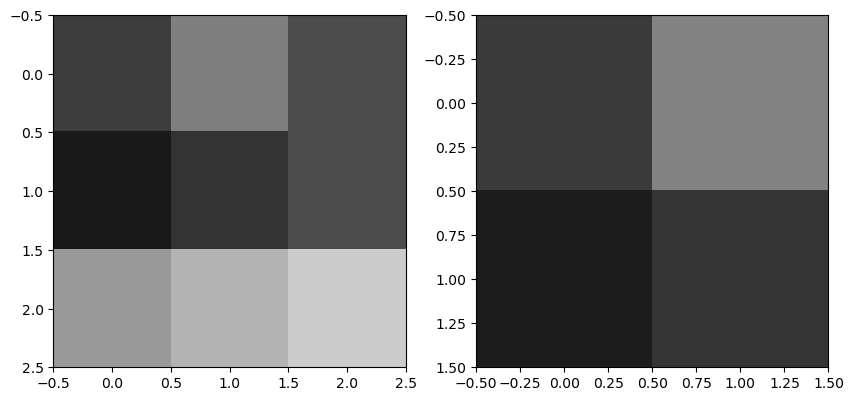

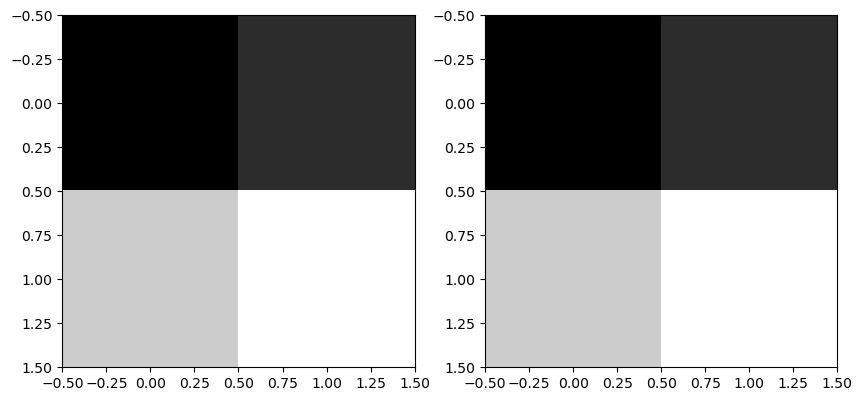

In [50]:
# test cpu vs gpu
test_sample = np.array([[0.24, 0.50, 0.30], [0.10, 0.20, 0.30], [0.60, 0.70, 0.80]])
test_sample_tensor = torch.nn.functional.unfold(torch.tensor(test_sample, dtype=torch.float32, device=device).reshape(1, 3, 3), kernel_size=2, stride=1).permute(1,0).reshape(-1,2,2)

test_window = np.array([[0.23, 0.51],[0.11, 0.21]])
test_mask = np.array([[1, 1],[1, 1]])
fig, axes = plt.subplots(1,2, figsize=(10,10))
axes[0].imshow(test_sample, cmap='gray', vmin=0, vmax=1)
axes[1].imshow(test_window, cmap='gray', vmin=0, vmax=1)

cpu_ssd = ssd_x_gaussian(test_sample, test_window, test_mask)
gpu_ssd = ssdnorm_cuda(test_sample_tensor, test_window, test_mask)

print('cpu', cpu_ssd)
print('gpu', gpu_ssd.reshape(2,2))

fig, axes = plt.subplots(1,2, figsize=(10,10))
axes[0].imshow(cpu_ssd, cmap='gray')
axes[1].imshow(gpu_ssd.reshape(2,2).cpu(), cmap='gray')

print(np.min(cpu_ssd))
print(torch.min(gpu_ssd))

torch.Size([1, 530, 530])
torch.Size([81, 272484])
torch.Size([272484, 81])
torch.Size([272484, 9, 9])


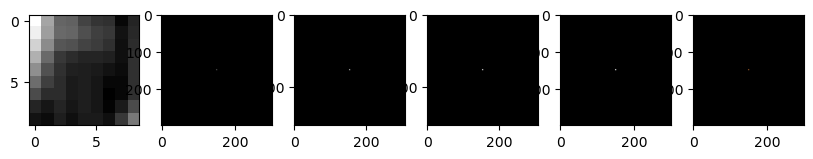

In [8]:
gen_dim = (300,300)

windowsize = 9
sample, window, mask, pad_window, pad_mask, pic_gen  = init_gpu(image_array, windowsize, gen_dim)
# sample_cpu, window_cpu, mask_cpu, pad_window_cpu, pad_mask_cpu, pic_gen_cpu  = init_cpu(image_array, windowsize, gen_dim)

fig, axes = plt.subplots(1,6, figsize=(10,10))
axes[0].imshow(sample[0].cpu(), cmap='gray')
axes[1].imshow(window, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(pad_window, cmap='gray')
axes[3].imshow(pad_mask, cmap='gray')
axes[4].imshow(mask, cmap='gray')
axes[5].imshow(pic_gen)

In [9]:
def gen_picture(image_array, gen_dim, windowsize, sample_size):
    sample, window, mask, pad_window, pad_mask, pic_gen  = init_gpu(image_array, windowsize, gen_dim)
    while np.sum(mask) != gen_dim[0] * gen_dim[1]:
        dilated_image = cv2.dilate(mask, np.ones((3,3)), iterations=1)
        new_mask = dilated_image - mask
        new_indices = np.where(new_mask == 1)
        # fig, axes = plt.subplots(new_indices[0].shape[0], 6, figsize=(6,new_indices[0].shape[0]))
        # cnt = 0
        #print('I count', new_indices[0].shape, 'new indices')
        for x, y in zip(new_indices[0], new_indices[1]):
            sub_pic = pad_window[x:x+windowsize, y:y+windowsize]
            sub_mask = pad_mask[x:x+windowsize, y:y+windowsize]

            #axes[cnt][0].imshow(sub_pic)
            #axes[cnt][0].set_title(f'{x},{y}')
            #print(x,y)

            # '''cpu version'''
            # sub_pic_cpu = pad_window_cpu[x:x+windowsize, y:y+windowsize]
            # sub_mask_cpu = pad_mask_cpu[x:x+windowsize, y:y+windowsize]
            # ssds_cpu = ssd_x_gaussian(sample_cpu, sub_pic_cpu, sub_mask_cpu)
            # min_ssd_cpu = np.min(ssds_cpu)
            # min_threshold_cpu = min_ssd_cpu * 1.1
            # indices_cpu = np.where(ssds_cpu <= min_threshold_cpu)
            # N = indices_cpu[0].shape[0]
            # select_cpu = np.random.choice(np.arange(N), size=1, p=np.ones(N) / float(N))
            # shift_amount_cpu = (windowsize) // 2
            # sample_index_cpu = (indices_cpu[0][select_cpu][0] + shift_amount_cpu, indices_cpu[1][select_cpu][0] + shift_amount_cpu)

            # window_cpu[x,y] = sample_cpu[sample_index_cpu]
            # pic_gen_cpu[x,y] = image_array[sample_index_cpu[0], sample_index_cpu[1]]
            # mask_cpu[x,y] = 1

            # context_patch_cpu = image_array[sample_index_cpu[0] - windowsize//2 : sample_index_cpu[0] + windowsize//2,
            #                             sample_index_cpu[1] - windowsize//2 : sample_index_cpu[1] + windowsize//2]
            # ''''''

            ssds = ssdnorm_cuda(sample, sub_pic, sub_mask)
            #print('cumulative ssds', ssds.shape)
            #nonzero_ssds = ssds[ssds != 0]
            min_ssd = torch.min(ssds)
            # print('min ssd found:', min_ssd, min_ssd_cpu)
            min_threshold = min_ssd * (1.1)
            indices = torch.where(ssds <= min_threshold)
            # if im :
            #     up_left_diag_set.append(indices[0])
            #print('indices:', indices[0].shape[0], indices)
            #print('indices cpu:', indices_cpu[0].shape[0], indices_cpu)
            # print('found:', indices[0].shape[0], 'found in cpu:', indices_cpu[0].shape[0])
            N = indices[0].shape[0]
            select = np.random.choice(np.arange(N), size=1, p=np.ones(N) / float(N))
            # if im :
            #     up_left_diag_chosen.append(indices[0][select])

            #print('select: ', select, indices[0][select])
            shift_amount = windowsize // 2
            sample_index = indices[0][select].item()

            window[x,y] = sample[sample_index][shift_amount, shift_amount].item()
            decoded_y = sample_index // (sample_size[0] - windowsize + 1)
            decoded_x = sample_index % (sample_size[1] - windowsize + 1)
            pic_gen[x,y] = image_array[decoded_y + windowsize//2,
                                       decoded_x + windowsize//2, :]
            mask[x,y] = 1
    return pic_gen


torch.Size([1, 530, 530])
torch.Size([225, 266256])
torch.Size([266256, 225])
torch.Size([266256, 15, 15])
I count (16,) new indices
I count (24,) new indices
I count (32,) new indices
I count (40,) new indices
I count (48,) new indices
I count (56,) new indices
I count (64,) new indices


I count (72,) new indices
I count (80,) new indices
I count (88,) new indices
I count (96,) new indices
I count (104,) new indices
I count (112,) new indices
I count (120,) new indices
I count (128,) new indices
I count (136,) new indices
I count (144,) new indices
I count (152,) new indices
I count (160,) new indices
I count (168,) new indices
I count (176,) new indices
I count (184,) new indices
I count (192,) new indices
I count (200,) new indices
I count (208,) new indices
I count (216,) new indices
I count (224,) new indices
I count (232,) new indices
I count (240,) new indices
I count (248,) new indices
I count (256,) new indices
I count (264,) new indices
I count (272,) new indices
I count (280,) new indices
I count (288,) new indices
I count (296,) new indices
I count (304,) new indices
I count (312,) new indices
I count (320,) new indices
I count (328,) new indices
I count (336,) new indices
I count (344,) new indices
I count (352,) new indices
I count (360,) new indices
I cou

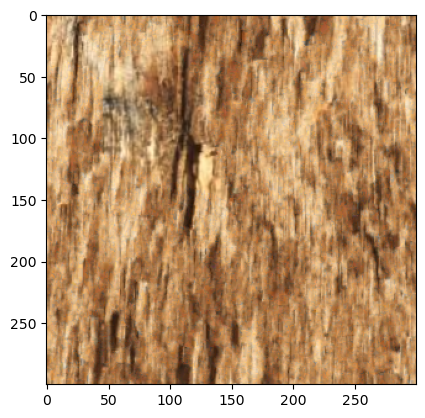

In [10]:
gen_dim = (300,300)
windowsize = 15
box = 2
pic_out = gen_picture(image_array, gen_dim, windowsize, sample_size)
plt.imshow(pic_out, cmap='gray', vmin=0, vmax=1)

In [ ]:
# view random patches from sample
rand_number_h = np.random.choice(np.arange(image_array.shape[0] - gen_dim[0]), size=1,
                                 p=np.ones(image_array.shape[0] - gen_dim[0]) / float(image_array.shape[0] - gen_dim[0]))
rand_number_w = np.random.choice(np.arange(image_array.shape[1] - gen_dim[1]), size=1,
                                 p=np.ones(image_array.shape[1] - gen_dim[1]) / float(image_array.shape[1] - gen_dim[1]))
rand_patch = image_array[rand_number_h[0]:rand_number_h[0] + gen_dim[0], rand_number_w[0]:rand_number_w[0] + gen_dim[1]]
fig, axes = plt.subplots(1,1,figsize=(10,10))
axes.imshow(rand_patch)
axes.axis('off')

# SAVE THE GENERATED IMAGE

In [ ]:
plt.imsave('wow.png', pic_gen)
print("Image saved using OpenCV!")

In [4]:
image = Image.open('Assignment2/3.png')
image_array = np.array(image)
image_array_mud = image_array[:,:,:3]
sample_size_mud = image_array.shape
image = Image.open('Assignment2/4.png')
image_array = np.array(image)
image_array_leaf = image_array[:,:,:3]
sample_size_leaf = image_array.shape
image = Image.open('Assignment2/9.png')
image_array = np.array(image)
image_array_moss = image_array[:,:,:3]
sample_size_moss = image_array.shape
image = Image.open('Assignment2/5.png')
image_array = np.array(image)
image_array_flower = image_array[:,:,:3]
sample_size_flower = image_array.shape
print(sample_size_mud, sample_size_leaf, sample_size_moss, sample_size_flower)

(530, 530, 4) (530, 529, 4) (530, 531, 4) (530, 529, 4)


In [31]:
gen_dim = (300,300)
windowsize = 9
fig, axes = plt.subplots(4,2, figsize=(20,20))

pic_out = gen_picture(image_array_mud, gen_dim, windowsize, sample_size_mud)
axes[0][0].imshow(pic_out, cmap='gray', vmin=0, vmax=1)
axes[0][1].imshow(image_array_mud, cmap='gray', vmin=0, vmax=1)

pic_out = gen_picture(image_array_leaf, gen_dim, windowsize, sample_size_leaf)
axes[1][0].imshow(pic_out, cmap='gray', vmin=0, vmax=1)
axes[1][1].imshow(image_array_leaf, cmap='gray', vmin=0, vmax=1)

pic_out = gen_picture(image_array_moss, gen_dim, windowsize, sample_size_moss)
axes[2][0].imshow(pic_out, cmap='gray', vmin=0, vmax=1)
axes[2][1].imshow(image_array_moss, cmap='gray', vmin=0, vmax=1)

pic_out = gen_picture(image_array_flower, gen_dim, windowsize, sample_size_flower)
axes[3][0].imshow(pic_out, cmap='gray', vmin=0, vmax=1)
axes[3][1].imshow(image_array_flower, cmap='gray', vmin=0, vmax=1)

(530, 529, 3)